# Machine Learning Pipelines and GridSearchCV

## Introduction

<p>In machine learning workflows, the Pipeline class from <code>scikit-learn</code> is invaluable for streamlining data preprocessing and model training into a single, coherent sequence. A pipeline is essentially a sequence of data transformers that culminates with an optional final predictor. This structure enables seamless integration of preprocessing and predictive modeling, ensuring that the same data transformations applied during training are coonsistently applied to new data during prediction.</p>
<p>Each intermediate step in a pipeline must be a transformer, meaning it should implement both fit and transform methods. The final step, which is typically a predictive model, or estimator, only requires a fit method. The entire pipeline can be trained simultaneously using a method like <code>GridSearchCV</code>, resulting in self-contained predictor that can be used to make predictions on unseen data.</p>
<p>Importantly, the pipeline allows you to set the parameters of each of these steps using their names and parameter names connected by a double underscore <code>__</code>. For example, if a pipeline step is named <code>imputer</code> and you want to change its strategy, you can pass a parameter like <code>imputer__strategy="median"</code>. Additionally, steps can be entirely swapped out by assigning a different estimator or even bypassed by setting them to <code>"passthrough"</code> or <code>None</code>.</p>
<p>A major advantage of using a pipeline is that it enables comprehensive cross-validation and hyperparameter tuning for all steps simultaneously. By integrating the pipeline within <code>GridSearchCV</code>, you can fine-tune not only the model but also the preprocessing steps, leading to optimized overall performance. Pipelines are essential for scenarios where preprocessing involves estimators performing operations like scaling, encoding categorical variables, imputing missing values, and dimensionality reduction. Pipelines ensure these steps are reproducibly applied to both training and test data.</p>

## Import required libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from numpy.typing import NDArray
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline

## Train a model using a pipeline

### Load the Iris dataset

In [2]:
data = load_iris()
X: NDArray[np.float64] = data.data
y: NDArray[np.int64] = data.target
labels: NDArray[np.str_] = data.target_names

### Instantiate a pipeline consisting of `StandardScaler`, `PCA` and `KNeighborsClassifier`

In [3]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

### Split the data into training and test sets

In [4]:
split_data: list[NDArray] = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = split_data

### Fit the pipeline on the training set

<p>The pipeline consists of a sequence of three estimators, and should be viewed as the machine learning model we are training and testing.</p>

In [5]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'


<p>Measure the pipeline accuracy on the test data.</p>

In [6]:
round(pipeline.score(X_test, y_test), 3)

0.9

### Get the model predictions

In [7]:
y_pred = pipeline.predict(X_test)

### Generate the confusion matrix for the KNN model and plot it

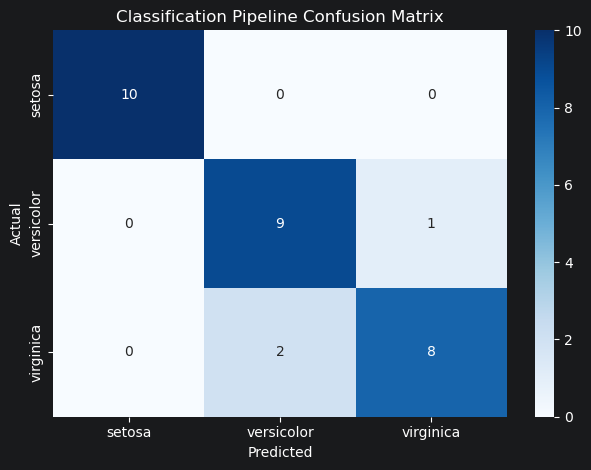

In [8]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=labels, yticklabels=labels)
plt.title("Classification Pipeline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

<p>The model incorrectly classified two viginica irises as versicolor, and one versicolor as virginica. Not bad, only three classification errors out of thirty irises on our first attempt.</p>

## Tune hyperparameters using a pipeline within cross-validation grid search

<p>We created a model but haven't yet attempted to optimize its performance. Let's see if we can do better. Recall that it would be a mistake to keep running the model over and over again with different hyperparameters to find the best one.</p>
<p>You would effectively be overfitting the model to your test dataset. The correct way to handle this tuning is to use cross validation.</p>

### Instantiate the pipeline

<p>We'll preprocess the data by scaling it and transforming it onto a to-be-determined number of principle components, follow that up with KNN model classifier, and combine these estimators into a pipeline. We'll then optimize the pipeline using cross validation over a hyperparameter grid search. This will allow us to find the best model for the set of trial hyperparameters.</p>

In [9]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("knn", KNeighborsClassifier())
])

### Define a model parameter grid to search over

In [10]:
param_grid = {
    "pca__n_components": [2, 3],
    "knn__n_neighbors": [3, 5, 7]
}

### Choose a cross validation method

<p>To ensure the target is tratified, we can use <code>scikit-learn</code>'s <code>StratifiedKFold</code> cross validation class.</p>

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Determine the best parameters

In [12]:
best_model = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring="accuracy", verbose=2)

### Fit the best `GridSearchCV` model to the training data

In [13]:
best_model.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_c

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [3, 5, ...], 'pca__n_components': [2, 3]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


<p>Go ahead and explore the <code>GridSearchCV</code> graphic that describes your estimator's structure, including the hyperparameters found for the best estimator. You can get specific help on each components by clicking on its question mark.</p>

### Evaluate the accuracy of the best model on the test set

In [14]:
round(best_model.score(X_test, y_test), 3)

0.933

<p>We've made a great accuracy improvement from 90% to 93%.</p>

### Display the best parameters

In [15]:
best_model.best_params_

{'knn__n_neighbors': 3, 'pca__n_components': 3}

### Plot the confusion matrix for the predictions on the test set

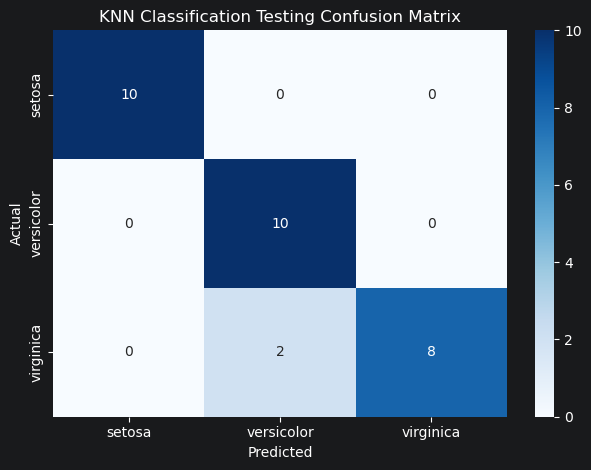

In [16]:
y_pred = best_model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=labels, yticklabels=labels)
plt.title("KNN Classification Testing Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

<p>That's impressive, only two errors where the predictions were Versicolor but the iris was actually a Virginica.</p>

****
This is the end of the file.
****